In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df = pd.read_csv("salary_data_cleaned.csv")
df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,Max Salary,Avg Salary,State,Same State,Company Age,Python,R,AWS,Spark,Excel
0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,...,91,72.0,NM,0,53,1,0,0,0,1
1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,...,112,87.5,MD,0,42,1,0,0,0,0
2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,...,90,85.0,FL,1,16,1,0,0,1,1
3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,...,97,76.5,WA,1,61,1,0,0,0,0
4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,...,143,114.5,NY,1,28,1,0,0,0,1


We simplify the Job Titles so its easier to group them

In [74]:
def title_simplifier(title):
    if 'data scientist' in title.lower():
        return 'data scientist'
    elif 'data engineer' in title.lower():
        return 'data engineer'
    elif 'analyst' in title.lower():
        return 'analyst'
    elif 'manager' in title.lower():
        return 'manager' 
    elif 'machine learning' in title.lower():
        return 'mle'
    elif 'director' in title.lower():
        return 'director'
    else:
        return 'na'

def seniority(title):
    if 'sr' in title.lower() or 'senior' in title.lower() or 'lead' in title.lower() or 'principal' in title.lower():
        return 'senior'
    elif 'jr' in title.lower() or 'jr.' in title.lower():
        return 'jr'
    else:
        return 'na'

In [75]:
df['Job Simplified'] = df['Job Title'].apply(title_simplifier)
df['Job Simplified'].value_counts()

Job Simplified
data scientist    279
na                184
data engineer     119
analyst           102
manager            22
mle                22
director           14
Name: count, dtype: int64

In [76]:
df['Seniority'] = df['Job Title'].apply(seniority)
df['Seniority'].value_counts()

Seniority
na        520
senior    220
jr          2
Name: count, dtype: int64

Some values in State are 'Los Angeles' instead of La

In [77]:
df['State'] = df['State'].apply(lambda x : 'CA' if x==' Los Angeles' else x)

Make a column for job description length

In [78]:
df['Desc Length'] = df['Job Description'].apply(lambda x : len(x))
df['Desc Length']

0      2536
1      4783
2      3461
3      3883
4      2728
       ... 
737    6162
738    6130
739    3078
740    1642
741    3673
Name: Desc Length, Length: 742, dtype: int64

Next we add a field for competitor count

In [79]:
df['Competitor Count'] = df['Competitors'].apply(lambda x : len(x.split(',')) if x!='-1' else 0)
df['Competitor Count']

0      0
1      0
2      0
3      3
4      3
      ..
737    3
738    3
739    0
740    0
741    0
Name: Competitor Count, Length: 742, dtype: int64

Convert hourly wage to annual wage

In [80]:
df['Min Salary'] = df.apply(lambda x : x['Min Salary']*2 if x['Hourly']==1 else x['Min Salary'], axis=1)

In [81]:
df['Max Salary'] = df.apply(lambda x : x['Max Salary']*2 if x['Hourly']==1 else x['Max Salary'], axis=1)

Now to start the EDA process

In [82]:
df.describe()

,Rating,Founded,Hourly,Employer Provided,Min Salary,Max Salary,Avg Salary,Same State,Company Age,Python,R,AWS,Spark,Excel,Desc Length,Competitor Count
count,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000
mean,3.618868,1837.154987,0.032345,0.039084,74.719677,128.149596,100.626011,0.557951,52.187332,0.528302,0.001348,0.237197,0.225067,0.522911,3869.545822,1.053908
std,0.801210,497.183763,0.177034,0.193925,30.980593,45.220324,38.855948,0.496965,54.156829,0.499535,0.036711,0.425651,0.417908,0.499812,1521.495868,1.384239
min,-1.000000,-1.000000,0.000000,0.000000,15.000000,16.000000,13.500000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.000000,0.000000
25%,3.300000,1939.000000,0.000000,0.000000,52.000000,96.000000,73.500000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2801.000000,0.000000
50%,3.700000,1988.000000,0.000000,0.000000,69.500000,124.000000,97.500000,1.000000,30.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3731.000000,0.000000
75%,4.000000,2007.000000,0.000000,0.000000,91.000000,155.000000,122.500000,1.000000,65.000000,1.000000,0.000000,0.000000,0.000000,1.000000,4740.000000,3.000000
max,5.000000,2019.000000,1.000000,1.000000,202.000000,306.000000,254.000000,1.000000,282.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10051.000000,4.000000


<Axes: >

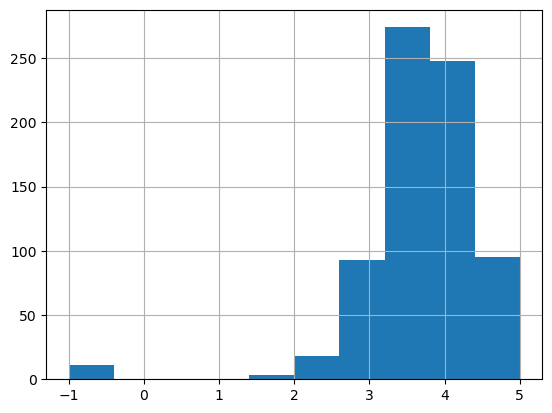

In [83]:
df.Rating.hist()

<Axes: >

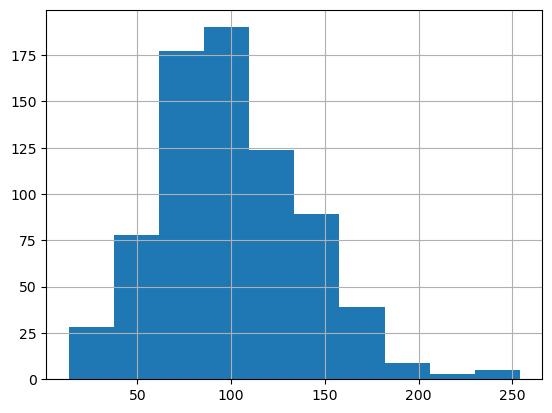

In [84]:
df['Avg Salary'].hist()

<Axes: >

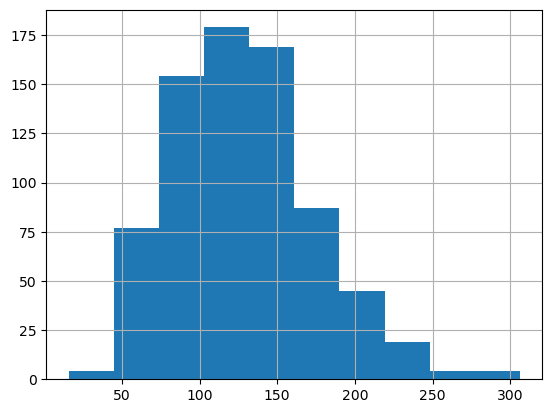

In [85]:
df['Max Salary'].hist()

<Axes: >

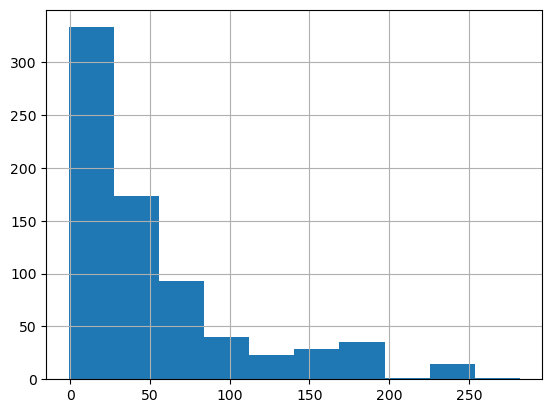

In [86]:
df['Company Age'].hist()

<Axes: >

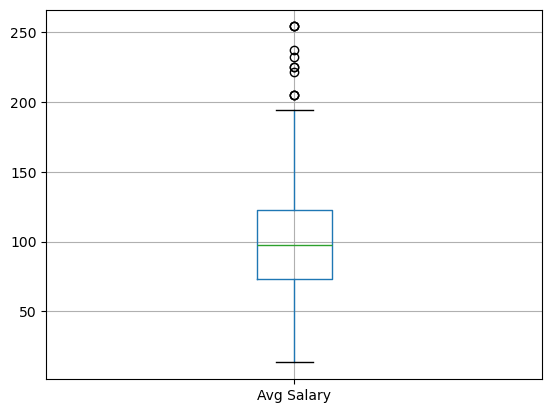

In [87]:
df.boxplot(column=['Avg Salary'])

<Axes: >

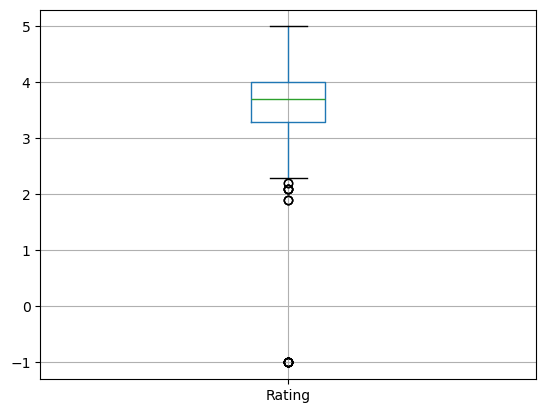

In [88]:
df.boxplot(column=['Rating'])

In [89]:
df[['Company Age','Avg Salary','Rating','Desc Length']].corr()

,Company Age,Avg Salary,Rating,Desc Length
Company Age,1.000000,0.019163,0.030637,0.165514
Avg Salary,0.019163,1.000000,0.013492,0.078808
Rating,0.030637,0.013492,1.000000,-0.012281
Desc Length,0.165514,0.078808,-0.012281,1.000000


<Axes: >

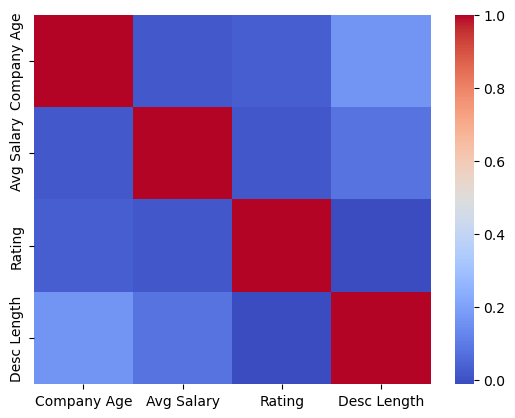

In [90]:
sns.heatmap(df[['Company Age','Avg Salary','Rating','Desc Length']].corr(), cmap='coolwarm')

In [91]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Hourly', 'Employer Provided', 'Min Salary', 'Max Salary', 'Avg Salary',
       'State', 'Same State', 'Company Age', 'Python', 'R', 'AWS', 'Spark',
       'Excel', 'Job Simplified', 'Seniority', 'Desc Length',
       'Competitor Count'],
      dtype='object')

In [92]:
df_cat = df[['Company Name','Location', 'Headquarters', 'Size','Type of ownership', 'Industry', 'Sector','Revenue','State', 'Same State', 'Python', 'R', 'AWS', 'Spark',
       'Excel', 'Job Simplified', 'Seniority']]

Graph for Company Name. Total = 20


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


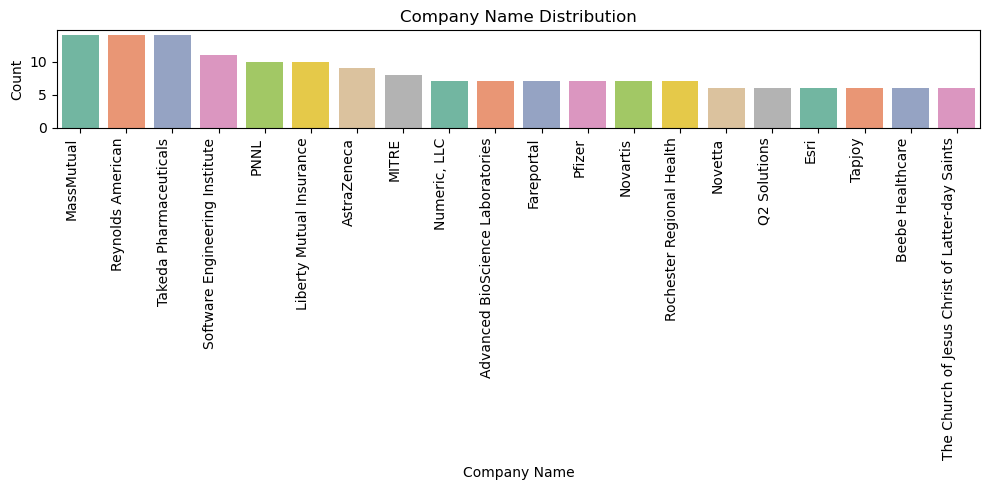

Graph for Location. Total = 20


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


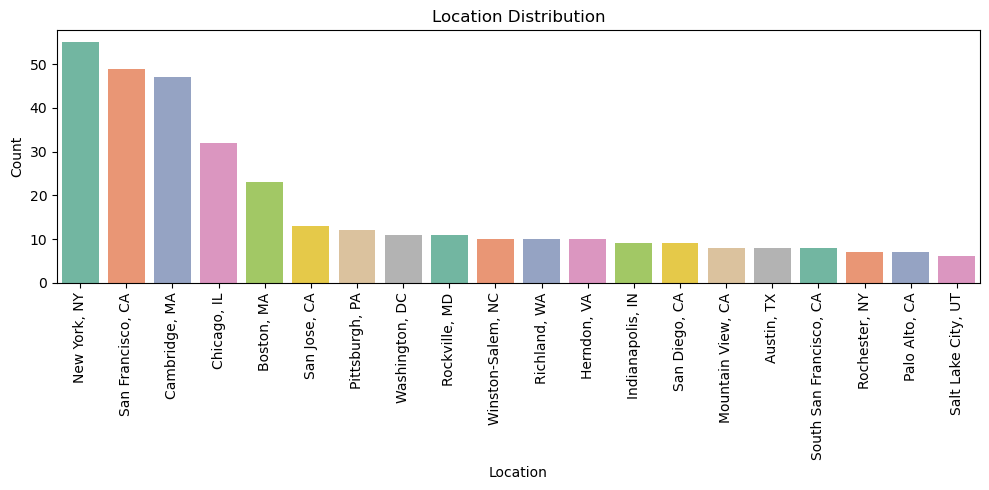

Graph for Headquarters. Total = 20


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


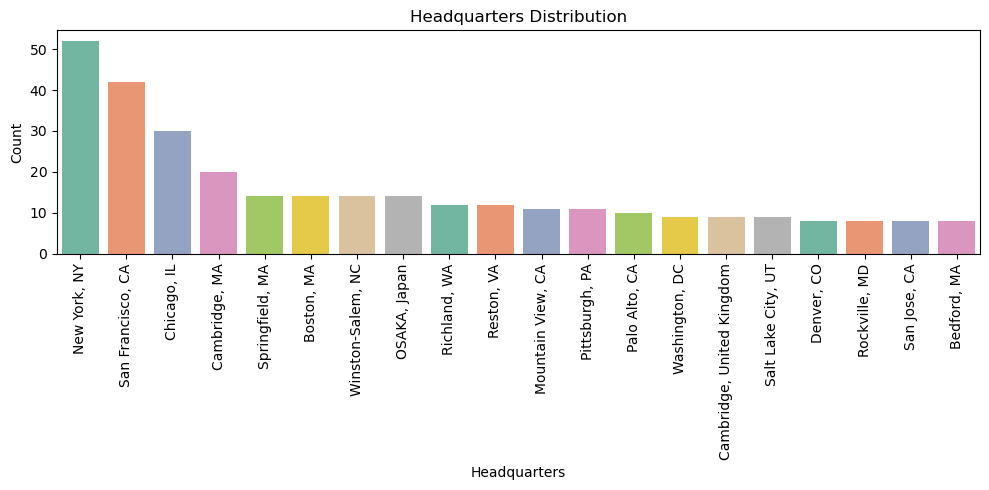

Graph for Size. Total = 9


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


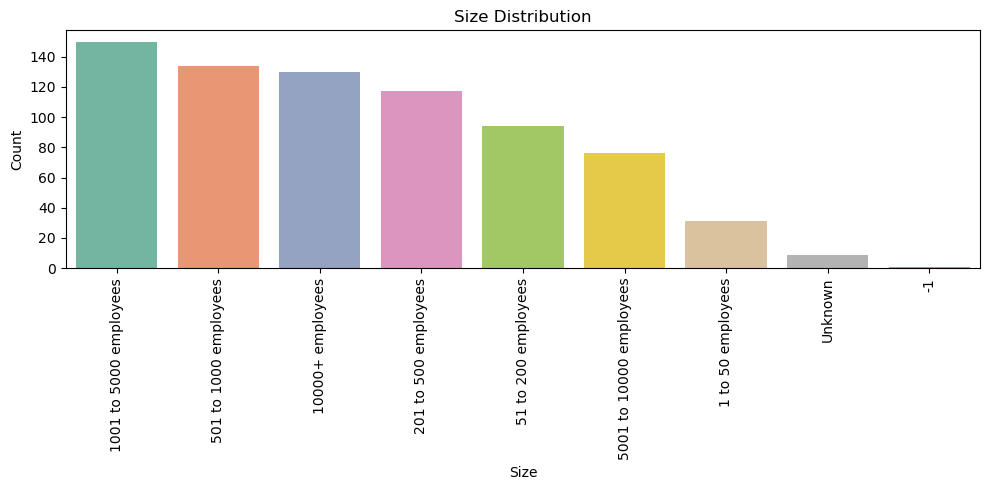

Graph for Type of ownership. Total = 11


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


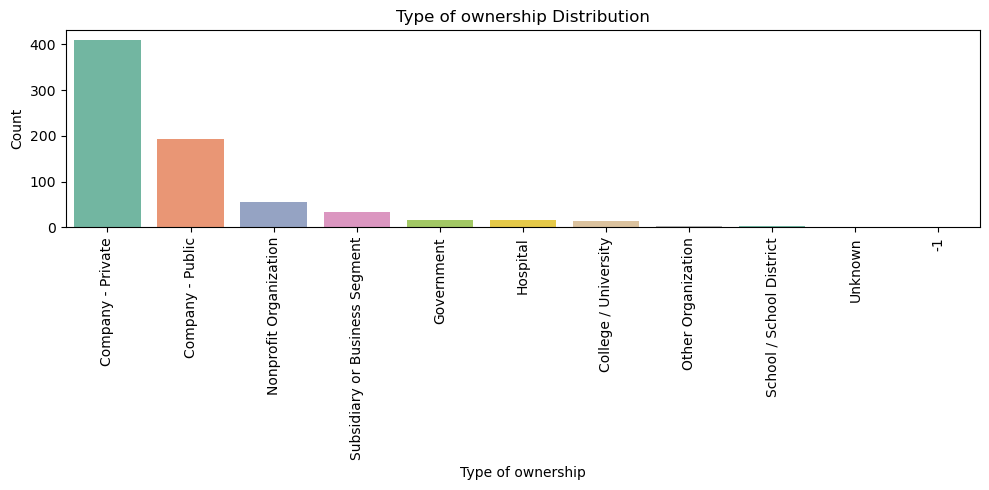

Graph for Industry. Total = 20


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


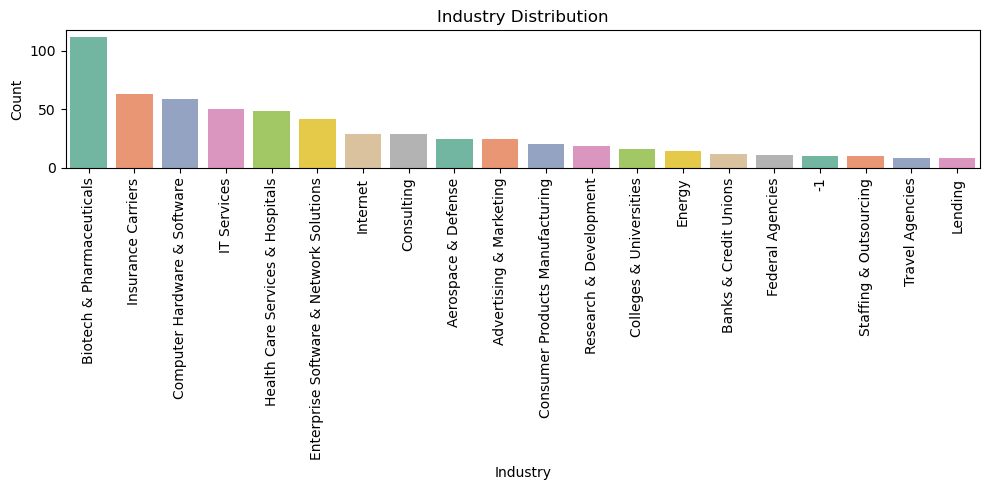

Graph for Sector. Total = 20


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


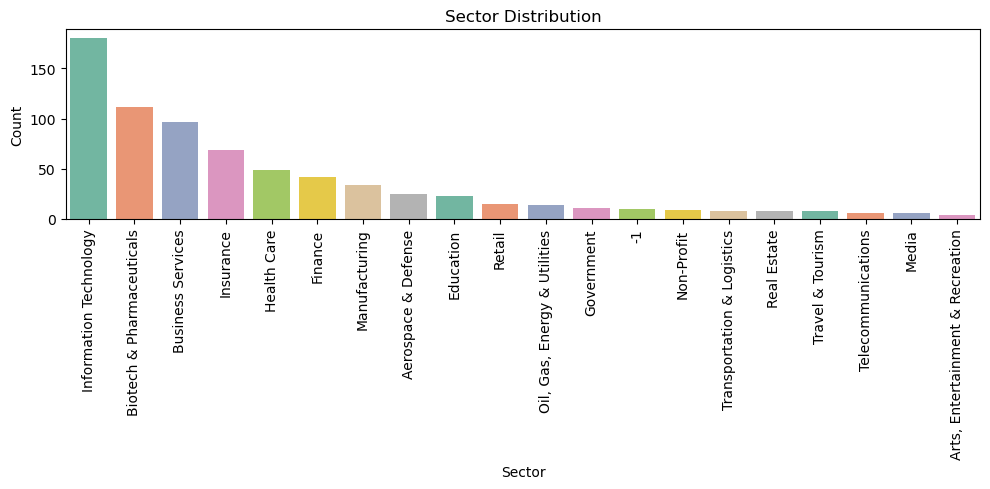

Graph for Revenue. Total = 14


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


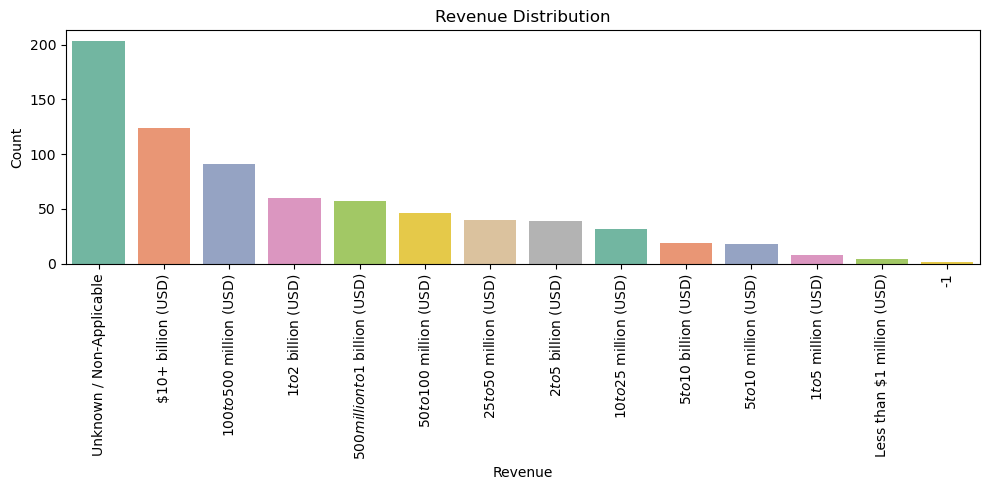

Graph for State. Total = 20


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


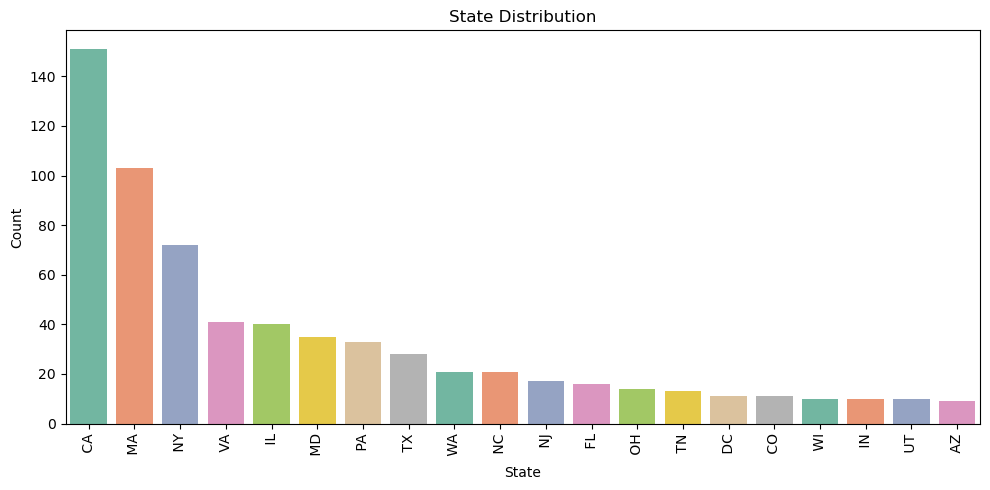

Graph for Same State. Total = 2


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


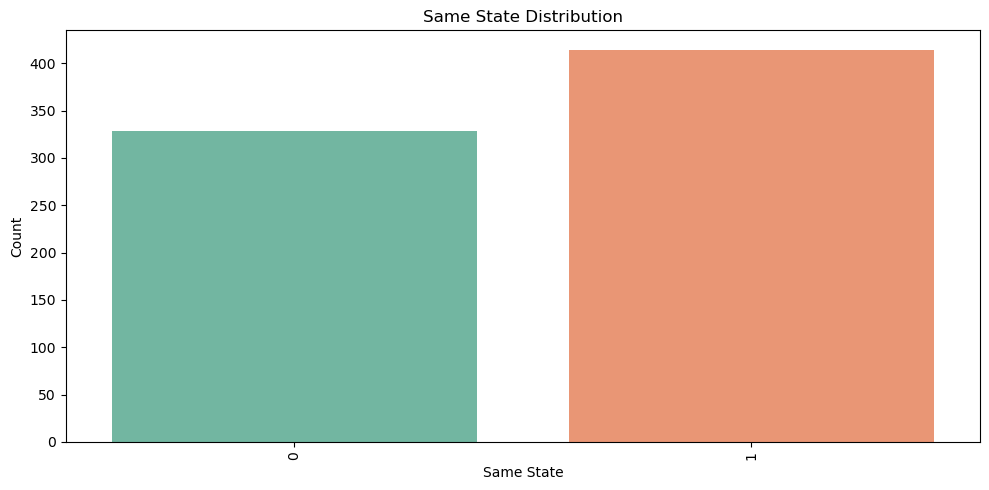

Graph for Python. Total = 2


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


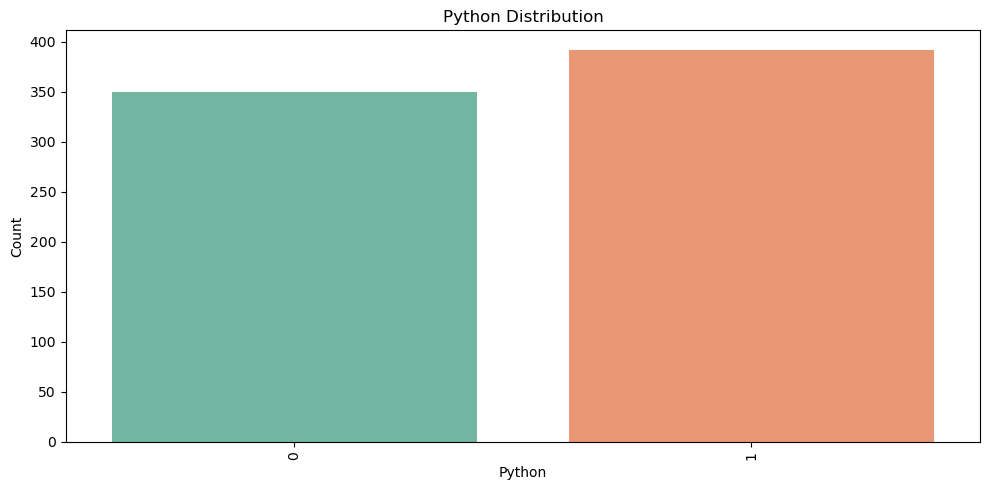

Graph for R. Total = 2


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


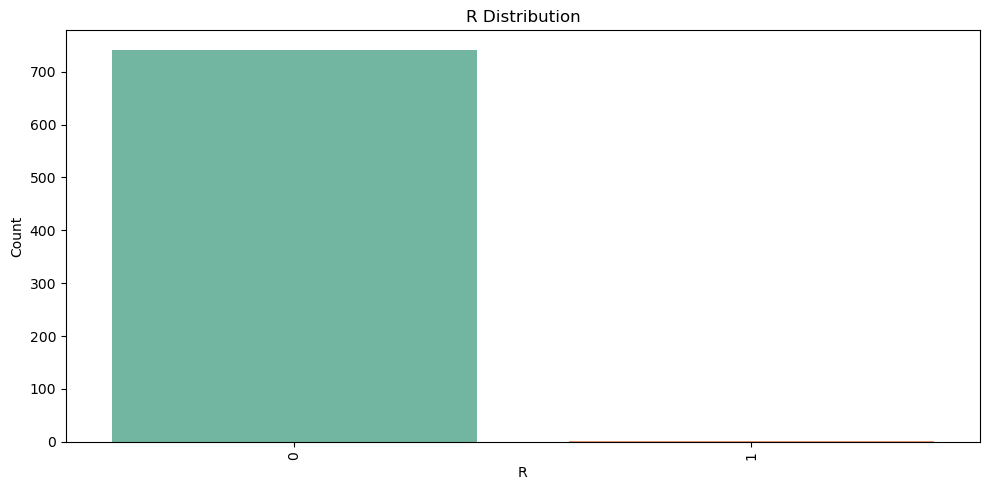

Graph for AWS. Total = 2


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


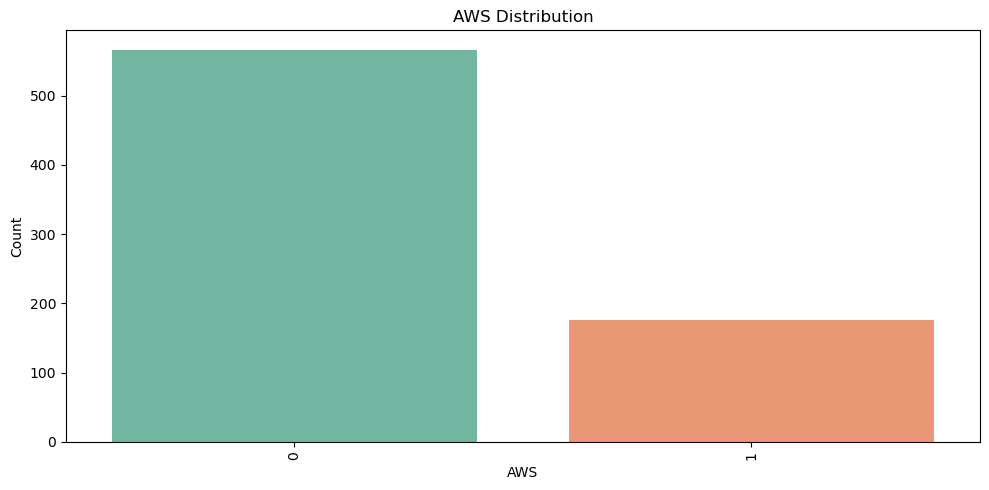

Graph for Spark. Total = 2


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


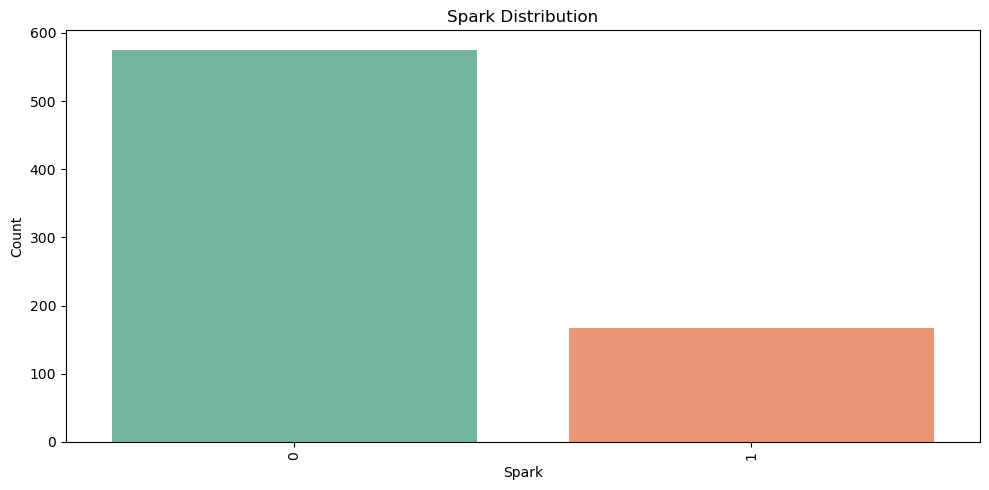

Graph for Excel. Total = 2


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


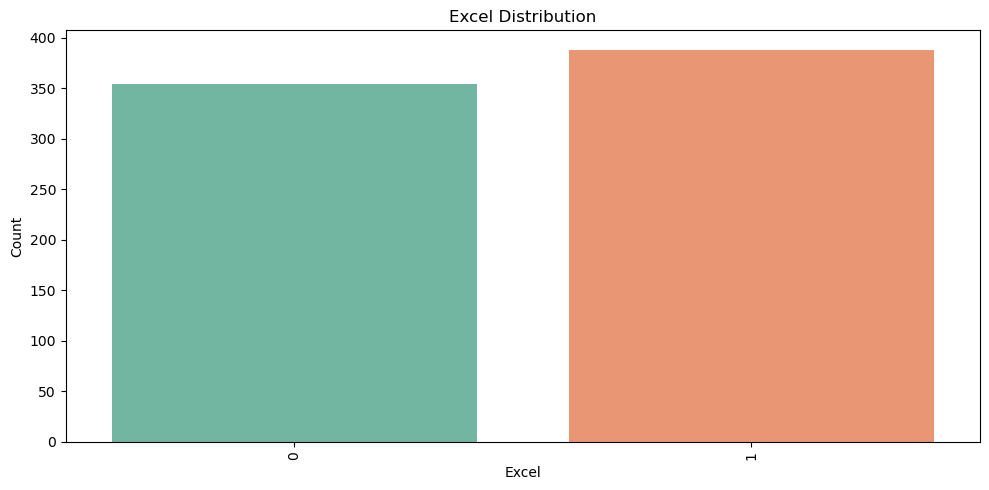

Graph for Job Simplified. Total = 7


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


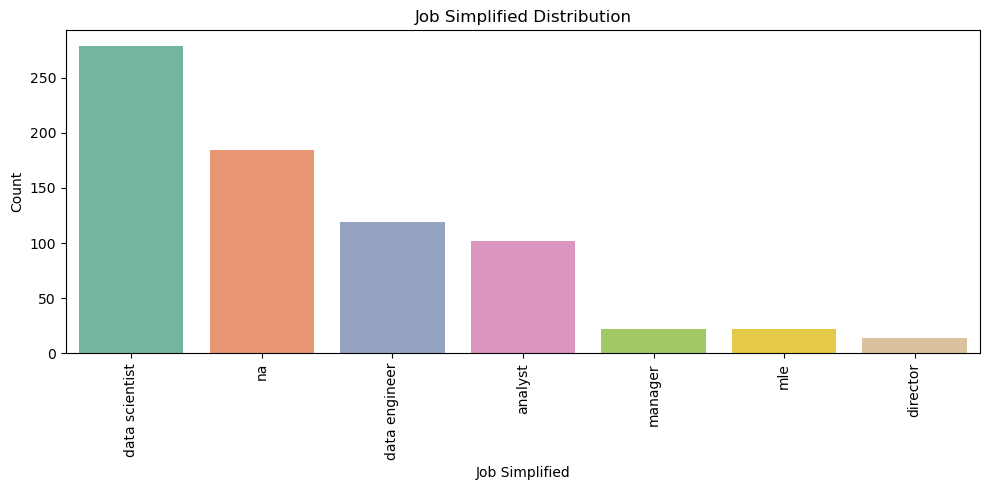

Graph for Seniority. Total = 3


C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
C:\Users\Aadi\AppData\Local\Temp\ipykernel_15936\449672573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


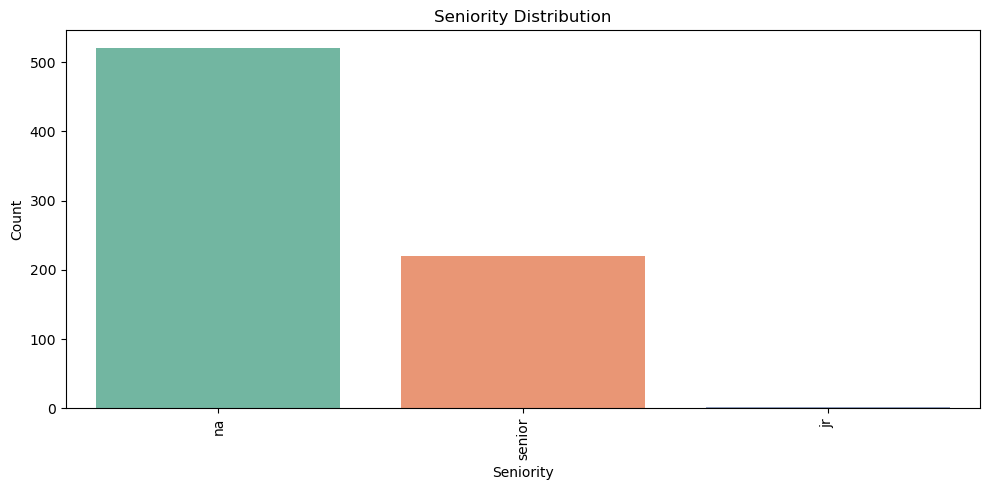

In [101]:
for i in df_cat.columns:
    cat_num = df_cat[i].value_counts().head(20)
    print(f"Graph for {i}. Total = {len(cat_num)}")
    plt.figure(figsize=(10, 5))
    chart = sns.barplot(x=cat_num.index, y=cat_num, palette="Set2")
    chart.set_title(f"{i} Distribution", fontsize=12)
    chart.set_xlabel(i, fontsize=10)
    chart.set_ylabel("Count", fontsize=10)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.tight_layout()
    plt.show()

In [103]:
pd.pivot_table(df, index = 'Job Simplified', values='Avg Salary')

,Avg Salary
Job Simplified,
analyst,65.857843
data engineer,105.403361
data scientist,117.564516
director,168.607143
manager,84.022727
mle,126.431818
na,84.853261


In [104]:
pd.pivot_table(df, index = ['Job Simplified', 'Seniority'], values='Avg Salary')

Avg Salary
Job Simplified Seniority            
analyst        jr          56.500000
               na          61.155405
               senior      79.092593
data engineer  na          96.701220
               senior     124.689189
data scientist jr         106.500000
               na         107.043011
               senior     138.956522
director       na         168.607143
manager        na          84.022727
mle            na         119.133333
               senior     142.071429
na             na          73.988189
               senior     109.061404

In [107]:
pd.pivot_table(df, index = 'State', values='Avg Salary').sort_values('Avg Salary', ascending=False)

,Avg Salary
State,
CA,123.619205
IL,116.662500
DC,110.181818
CA,107.500000
MA,106.281553
NJ,104.558824
MI,100.250000
RI,100.000000
NY,98.652778


In [109]:
pd.pivot_table(df, index = ['State','Job Simplified'], values='Avg Salary', aggfunc='count').sort_values('Avg Salary', ascending=False)

,,Avg Salary
State,Job Simplified,
CA,data scientist,67
MA,na,46
NY,data scientist,40
MA,data scientist,30
CA,na,27
...,...,...
OR,data engineer,1
NJ,na,1
SC,na,1
